In [1]:
# Крок 1. Імпорти та налаштування графіків

import warnings

import transformers
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
from transformers.pipelines import SUPPORTED_TASKS
from huggingface_hub.utils import logging as hub_logging
import sacrebleu
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
transformers.utils.logging.set_verbosity_error()
transformers.utils.logging.disable_progress_bar()
hub_logging.set_verbosity_error()

plt.rcParams["figure.figsize"] = (9, 3.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.linewidth"] = 0.3
plt.rcParams["grid.alpha"] = 0.5
plt.rcParams["font.size"] = 9

In [2]:
# Крок 2. Пробуємо найкоротший шлях, готовий пайплайн під переклад

print("версія transformers:", transformers.__version__)

try:
    pipeline("translation", model="Helsinki-NLP/opus-mt-uk-en")
    print("готовий пайплайн для перекладу є, можна користуватись ним")
except KeyError:
    print("готового пайплайна для перекладу в цій версії немає")
    print("перевіряємо, які задачі взагалі доступні:")
    for task in ("translation", "summarization", "text2text-generation", "text-generation"):
        print("   ", task, "-", "є" if task in SUPPORTED_TASKS else "немає")

# перекладу серед задач немає, тому далі працюємо з токенайзером і моделлю напряму

версія transformers: 5.14.1


готового пайплайна для перекладу в цій версії немає
перевіряємо, які задачі взагалі доступні:
    translation - немає
    summarization - немає
    text2text-generation - немає
    text-generation - є


In [3]:
# Крок 3. Текст, який будемо перекладати

sentences_uk = [
    "Океан займає понад сімдесят відсотків поверхні планети, але вивчений він гірше за Місяць.",
    "Найглибша точка світового океану лежить у Маріанській западині.",
    "Тиск на такій глибині у тисячу разів більший за атмосферний.",
    "Сонячне світло не проникає глибше двохсот метрів, тому там панує вічна темрява.",
    "Багато мешканців глибин світяться власним світлом, щоб приваблювати здобич.",
    "Перші батискафи опустилися на дно западини ще в тисяча дев'ятсот шістдесятому році.",
    "Сучасні апарати керуються дистанційно і можуть працювати під водою тижнями.",
    "Учені вважають, що більшість глибоководних видів досі не описана.",
]

# еталонний переклад потрібен, щоб потім порахувати метрику
reference_en = [
    "The ocean covers more than seventy percent of the planet's surface, "
    "but it is studied less than the Moon.",
    "The deepest point of the world ocean lies in the Mariana Trench.",
    "The pressure at such a depth is a thousand times higher than atmospheric pressure.",
    "Sunlight does not penetrate deeper than two hundred meters, "
    "so eternal darkness reigns there.",
    "Many inhabitants of the deep glow with their own light to attract prey.",
    "The first bathyscaphes descended to the bottom of the trench back in nineteen sixty.",
    "Modern vehicles are operated remotely and can work underwater for weeks.",
    "Scientists believe that most deep-sea species have still not been described.",
]

print("речень:", len(sentences_uk), "| еталонів:", len(reference_en))

речень: 8 | еталонів: 8


In [4]:
# Крок 4. Дві невеликі функції, щоб не повторювати код для кожної моделі

def load_model(name):
    tokenizer = AutoTokenizer.from_pretrained(name)
    model = AutoModelForSeq2SeqLM.from_pretrained(name)
    return tokenizer, model


def translate(tokenizer, model, texts, max_new_tokens=90):
    batch = tokenizer(texts, return_tensors="pt", padding=True)
    generated = model.generate(**batch, max_new_tokens=max_new_tokens)
    return tokenizer.batch_decode(generated, skip_special_tokens=True)

In [5]:
# Крок 5. Перша модель: opus-mt, навчена лише на пару українська-англійська

opus_tokenizer, opus_model = load_model("Helsinki-NLP/opus-mt-uk-en")
opus_out = translate(opus_tokenizer, opus_model, sentences_uk)

for src, dst in zip(sentences_uk, opus_out):
    print(src)
    print("   ->", dst)
    print()

Океан займає понад сімдесят відсотків поверхні планети, але вивчений він гірше за Місяць.
   -> The ocean covers over seventy percent of the earth's surface, but it is worse than the moon.

Найглибша точка світового океану лежить у Маріанській западині.
   -> The deepest point of the world's ocean lies in Mariana.

Тиск на такій глибині у тисячу разів більший за атмосферний.
   -> The pressure at this depth is a thousand times greater than the atmospheric pressure.

Сонячне світло не проникає глибше двохсот метрів, тому там панує вічна темрява.
   -> Sunlight does not penetrate more than 200 feet [2 m], so eternal darkness prevails.

Багато мешканців глибин світяться власним світлом, щоб приваблювати здобич.
   -> Many people in the deep shine with their light to attract prey.

Перші батискафи опустилися на дно западини ще в тисяча дев'ятсот шістдесятому році.
   -> The first submersibles sank to the bottom of the depression in the year nine hundred and sixty.

Сучасні апарати керуютьс

In [6]:
# Крок 6. Дивимось, що модель насправді отримує на вхід

batch = opus_tokenizer(sentences_uk[1], return_tensors="pt")
tokens = opus_tokenizer.convert_ids_to_tokens(batch["input_ids"][0])

print("речення:", sentences_uk[1])
print("слів:", len(sentences_uk[1].split()), "| токенів:", len(tokens))
print(tokens)

# токенів більше, ніж слів: рідкі слова ріжуться на частини
# останній токен </s> службовий, він позначає кінець рядка

речення: Найглибша точка світового океану лежить у Маріанській западині.
слів: 8 | токенів: 17
['▁Най', 'гли', 'б', 'ша', '▁точка', '▁світового', '▁океану', '▁лежить', '▁у', '▁Марі', 'ан', 'ській', '▁за', 'пад', 'ині', '.', '</s>']


In [7]:
# Крок 7. Дивимось, чи бачать українську інші моделі

probe = sentences_uk[0]
t5_tokenizer, t5_model = load_model("t5-base")
mt5_tokenizer = AutoTokenizer.from_pretrained("google/mt5-small")

candidates = (
    ("t5-base", t5_tokenizer),
    ("google/mt5-small", mt5_tokenizer),
    ("opus-mt-uk-en", opus_tokenizer),
)
for name, tokenizer in candidates:
    pieces = tokenizer.convert_ids_to_tokens(tokenizer(probe)["input_ids"])
    unknown = sum(1 for piece in pieces if piece == tokenizer.unk_token)
    print(f"{name:17} словник {len(tokenizer):>7} | токенів {len(pieces):>3} | невідомих {unknown}")

t5_try = translate(t5_tokenizer, t5_model, ["translate Ukrainian to English: " + probe])[0]
print()
print("що видає t5:", t5_try)

# у t5 кирилиця розсипається на невідомі токени, тому для нашої пари вона не годиться

t5-base           словник   32100 | токенів  70 | невідомих 21
google/mt5-small  словник  250100 | токенів  30 | невідомих 0
opus-mt-uk-en     словник   61587 | токенів  18 | невідомих 0



що видає t5: кеан ама онад смдест вдсоткв оверн ланети, але вивени вн ре а с.


In [8]:
# Крок 8. Друга робоча модель: nllb, у якій українська теж є

nllb_name = "facebook/nllb-200-distilled-600M"
nllb_tokenizer, nllb_model = load_model(nllb_name)


def nllb_translate(texts, src_lang, tgt_lang, max_new_tokens=90):
    nllb_tokenizer.src_lang = src_lang
    batch = nllb_tokenizer(texts, return_tensors="pt", padding=True)
    bos_id = nllb_tokenizer.convert_tokens_to_ids(tgt_lang)
    generated = nllb_model.generate(**batch, forced_bos_token_id=bos_id,
                                    max_new_tokens=max_new_tokens)
    return nllb_tokenizer.batch_decode(generated, skip_special_tokens=True)


nllb_out = nllb_translate(sentences_uk, "ukr_Cyrl", "eng_Latn")
for src, dst in zip(sentences_uk, nllb_out):
    print(src)
    print("   ->", dst)
    print()

# тут однією назвою моделі не обійтись, треба ще вказати мову джерела і мову перекладу

Океан займає понад сімдесят відсотків поверхні планети, але вивчений він гірше за Місяць.
   -> The ocean covers more than 70 percent of the planet's surface, but it is less well studied than the moon.

Найглибша точка світового океану лежить у Маріанській западині.
   -> The deepest point of the world's oceans lies in the Mariana West.

Тиск на такій глибині у тисячу разів більший за атмосферний.
   -> The pressure at this depth is a thousand times that of the atmosphere.

Сонячне світло не проникає глибше двохсот метрів, тому там панує вічна темрява.
   -> Sunlight does not penetrate more than 200 feet [200 m] deep, so there is eternal darkness.

Багато мешканців глибин світяться власним світлом, щоб приваблювати здобич.
   -> Many inhabitants of the deep shines their own light to attract prey.

Перші батискафи опустилися на дно западини ще в тисяча дев'ятсот шістдесятому році.
   -> The first batiscape descended to the bottom of the valley in the year one thousand nine hundred and s

In [9]:
# Крок 9. Складаємо переклади двох моделей поруч

results = {
    "opus-mt-uk-en": opus_out,
    "nllb-200-distilled-600M": nllb_out,
}

pd.set_option("display.max_colwidth", 70)
labels = [f"реч. {i + 1}" for i in range(len(sentences_uk))]

pd.DataFrame(results, index=labels)

,opus-mt-uk-en,nllb-200-distilled-600M
реч. 1,"The ocean covers over seventy percent of the earth's surface, but ...","The ocean covers more than 70 percent of the planet's surface, but..."
реч. 2,The deepest point of the world's ocean lies in Mariana.,The deepest point of the world's oceans lies in the Mariana West.
реч. 3,The pressure at this depth is a thousand times greater than the at...,The pressure at this depth is a thousand times that of the atmosph...
реч. 4,"Sunlight does not penetrate more than 200 feet [2 m], so eternal d...","Sunlight does not penetrate more than 200 feet [200 m] deep, so th..."
реч. 5,Many people in the deep shine with their light to attract prey.,Many inhabitants of the deep shines their own light to attract prey.
реч. 6,The first submersibles sank to the bottom of the depression in the...,The first batiscape descended to the bottom of the valley in the y...
реч. 7,Modern machines are operated remotely and can work under water for...,Modern machines are remotely operated and can operate underwater f...
реч. 8,Scientists believe that most deep - water species are still unknown.,Scientists believe that most deep-water species have not yet been ...


In [10]:
# Крок 10. Рахуємо BLEU по всьому набору речень

rows = []
for name, hypothesis in results.items():
    score = sacrebleu.corpus_bleu(hypothesis, [reference_en])
    rows.append((name, round(score.score, 2)))

bleu_table = pd.DataFrame(rows, columns=["модель", "BLEU"])
print(bleu_table.to_string(index=False))

# sacrebleu рахує BLEU у шкалі від 0 до 100
# речень усього вісім, тому число орієнтовне
# ще нюанс: еталон пише числа словами, а моделі цифрами, і за це BLEU теж знімає бали

                 модель  BLEU
          opus-mt-uk-en 36.82
nllb-200-distilled-600M 41.75


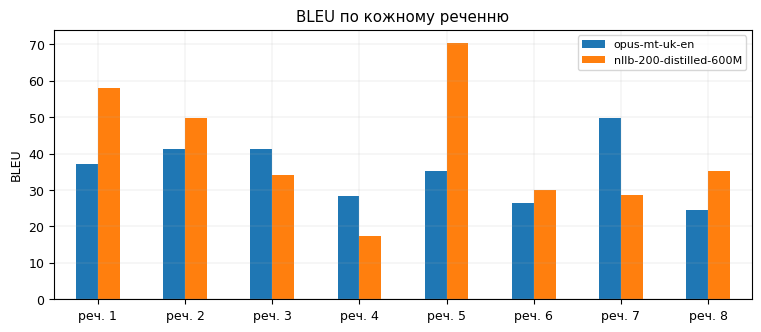

,opus-mt-uk-en,nllb-200-distilled-600M
реч. 1,37.2,57.9
реч. 2,41.4,49.7
реч. 3,41.4,34.1
реч. 4,28.4,17.5
реч. 5,35.2,70.5
реч. 6,26.5,29.9
реч. 7,49.7,28.6
реч. 8,24.4,35.1


In [11]:
# Крок 10. Дивимось BLEU окремо по кожному реченню

per_sentence = {}
for name, hypothesis in results.items():
    per_sentence[name] = [round(sacrebleu.sentence_bleu(h, [r]).score, 1)
                          for h, r in zip(hypothesis, reference_en)]

per_df = pd.DataFrame(per_sentence, index=labels)

per_df.plot(kind="bar", rot=0)
plt.title("BLEU по кожному реченню")
plt.ylabel("BLEU")
plt.legend(fontsize=8)
plt.show()

per_df

In [12]:
# Крок 11. Зворотний переклад: беремо англійський результат і повертаємо в українську

back_tokenizer, back_model = load_model("Helsinki-NLP/opus-mt-en-uk")
back_out = translate(back_tokenizer, back_model, opus_out)

for src, dst in zip(sentences_uk, back_out):
    print(src)
    print("   ->", dst)
    print()

back_score = sacrebleu.corpus_bleu(back_out, [sentences_uk])
print("BLEU між оригіналом і зворотним перекладом:", round(back_score.score, 2))

Океан займає понад сімдесят відсотків поверхні планети, але вивчений він гірше за Місяць.
   -> Океан покриває понад сімдесят відсотків земної поверхні, але він гірший від Місяця.

Найглибша точка світового океану лежить у Маріанській западині.
   -> Найглибша точка світового океану - Маріана.

Тиск на такій глибині у тисячу разів більший за атмосферний.
   -> На цій глибині тиск у тисячу разів більший, ніж атмосферний.

Сонячне світло не проникає глибше двохсот метрів, тому там панує вічна темрява.
   -> Сонячне світло не проникає в понад 2 метри, тому панує вічна темрява.

Багато мешканців глибин світяться власним світлом, щоб приваблювати здобич.
   -> Багато людей в глибині душі сяють зі світлом, щоб приваблювати здобич.

Перші батискафи опустилися на дно западини ще в тисяча дев'ятсот шістдесятому році.
   -> Перші батискафти опустилися на дно депресії у дев'ятисот шістдесятому році.

Сучасні апарати керуються дистанційно і можуть працювати під водою тижнями.
   -> Сучасні машини 

In [13]:
# Крок 12. Окремо дивимось на місця, де переклад поїхав

tricky = [0, 1, 3, 5]
for i in tricky:
    print(sentences_uk[i])
    print("   еталон:", reference_en[i])
    print("   opus:  ", opus_out[i])
    print("   nllb:  ", nllb_out[i])
    print()

Океан займає понад сімдесят відсотків поверхні планети, але вивчений він гірше за Місяць.
   еталон: The ocean covers more than seventy percent of the planet's surface, but it is studied less than the Moon.
   opus:   The ocean covers over seventy percent of the earth's surface, but it is worse than the moon.
   nllb:   The ocean covers more than 70 percent of the planet's surface, but it is less well studied than the moon.

Найглибша точка світового океану лежить у Маріанській западині.
   еталон: The deepest point of the world ocean lies in the Mariana Trench.
   opus:   The deepest point of the world's ocean lies in Mariana.
   nllb:   The deepest point of the world's oceans lies in the Mariana West.

Сонячне світло не проникає глибше двохсот метрів, тому там панує вічна темрява.
   еталон: Sunlight does not penetrate deeper than two hundred meters, so eternal darkness reigns there.
   opus:   Sunlight does not penetrate more than 200 feet [2 m], so eternal darkness prevails.
   nll

In [14]:
# Крок 13. Висновки
#
# Перекладали в одній парі мов: з української на англійську і назад.
# Сам переклад справді вміщується в кілька рядків: токенайзер, модель, generate, decode.
# У цій версії бібліотеки готового пайплайна для перекладу немає, тому працюємо напряму.
# Модель t5 для цієї пари не підійшла: кирилиці в її словнику майже немає,
# літери стають <unk>, і замість перекладу виходить набір уламків.
# Багатомовна mt5 з тієї ж родини бере українську чисто, у неї словник у вісім разів більший.
# Для перекладу взяли opus-mt і nllb, вони вже навчені саме на цю задачу.
# Модель opus-mt важить близько 300 МБ і знає лише одну пару мов.
# Модель nllb важить у рази більше, але знає близько двохсот мов.
# Щоб змінити модель, досить поміняти назву, але код однаковий не завжди:
# для nllb довелось окремо вказувати мову джерела і мову перекладу.
# За BLEU на всьому наборі nllb вийшла попереду: 41.8 проти 36.8.
# По окремих реченнях картина інша, на трьох із восьми opus-mt виявилась кращою.
# Обидві моделі спіткнулись на власній назві: западина стала Mariana і навіть Mariana West.
# Числівники словами теж далися важко, тисяча дев'ятсот шістдесятий став nine hundred and sixty.
# Найдивніше вийшло з метрами: обидві моделі видали 200 feet і дописали перерахунок у дужках.
# Зворотний переклад дав BLEU 27.8, і місцями зміст поїхав зовсім.
# Мешканці глибин перетворились на людей в глибині душі, а западина стала депресією.
# Тобто готова модель дає робочий чорновий переклад, але терміни і числа треба перевіряти.